# libKriging vs GPyTorch (Python)

This notebook compares **pylibkriging** and **GPyTorch** along two axes:

1. **Mimicry**: reproduce with `pylibkriging` a "default" Kriging fit
   equivalent to GPyTorch's `ExactGP` (Matern 5/2 kernel, constant mean,
   maximum likelihood via Adam), and check that both give near-identical
   predictions on a small design.
2. **Package-specific feature**: GPyTorch's headline feature is scaling
   *exact* GP inference past the O(n³) Cholesky wall by replacing the
   dense factorization with iterative linear algebra (conjugate gradients
   via BBMM, `LinearOperator` matrix-vector products, pivoted-Cholesky
   preconditioning) run on GPU. `pylibkriging`'s closest equivalent is a
   different trade: instead of solving the *same* exact system iteratively,
   `objective="LLNystrom(k)"` swaps in a *global low-rank* approximation of
   the covariance (rank k, O(n·k²) per evaluation, CPU only, see
   [Nystrom.md](../math/Nystrom.md)) -- an approximate objective rather than
   an iterative solve of the exact one. We compare fit time and predictive
   accuracy of the two approaches as n grows into the range where the exact
   O(n³) route (both packages' own exact-GP baseline) becomes impractical.


## 0. Installation / environment check

Requires `pylibkriging` (built from this repository) and `gpytorch` (with
`torch`), both importable from the same Python environment, with
`LD_LIBRARY_PATH` including `build/installed/lib` if libKriging was built
locally rather than installed as a wheel.


In [1]:
import importlib, sys

for pkg in ["pylibkriging", "torch", "gpytorch"]:
    if importlib.util.find_spec(pkg) is None:
        raise ImportError(
            f"'{pkg}' is not importable from {sys.executable}.\n"
            "Install pylibkriging (see bindings/Python/README.md) and "
            "'pip install torch gpytorch', and make sure LD_LIBRARY_PATH "
            "includes build/installed/lib if libKriging was built locally."
        )
print("pylibkriging and gpytorch are both importable - OK")


pylibkriging and gpytorch are both importable - OK


## 1. Load both packages

In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk
import torch
import gpytorch

torch.set_default_dtype(torch.float64)  # match pylibkriging's float64 throughout

print("pylibkriging loaded")
print("gpytorch version:", gpytorch.__version__, " torch version:", torch.__version__)


/home/richet/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


pylibkriging loaded
gpytorch version: 1.15.2  torch version: 2.13.0+cpu


## 2. Branin function and design of experiments

Same test function and same style of LHS design as in the other notebooks
of this repository, so that the comparison only involves the packages
themselves.


In [3]:
def branin(X):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    return ((x2 - 5 / (4 * np.pi ** 2) * x1 ** 2 + 5 / np.pi * x1 - 6) ** 2
             + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1) + 10)


def lhs(n, d, seed=42):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, d))
    for j in range(d):
        X[:, j] = (rng.permutation(n) - rng.random(n)) / n
    return X


n = 20
X = lhs(n, 2)
y = branin(X)
print(X.shape, y.shape)


(20, 2) (20,)


### Cross-section helper

In [4]:
def plot_slices(models, slice_vals=(0.25, 0.5, 0.75), true_fn=branin,
                 xlabel="x1"):
    x1_seq = np.linspace(0, 1, 200)
    colors = ["#1f78b4", "#e31a1c", "#33a02c", "#ff7f00"]
    fig, axes = plt.subplots(1, len(slice_vals), figsize=(18, 4.5), sharey=False)
    for ax, s in zip(axes, slice_vals):
        Xs = np.column_stack([x1_seq, np.full_like(x1_seq, s)])
        y_true = true_fn(Xs)
        ax.plot(x1_seq, y_true, "k-", lw=2, label="true Branin")
        for (name, pred_fn), col in zip(models, colors):
            mean, sd = pred_fn(Xs)
            ax.plot(x1_seq, mean, "--", color=col, lw=2, label=name)
            ax.fill_between(x1_seq, mean - sd, mean + sd, color=col, alpha=0.15)
        ax.set_title(f"slice x2={s}")
        ax.set_xlabel(xlabel)
        if ax is axes[0]:
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


## 3. Mimicry: `Kriging()` vs GPyTorch `ExactGP`

Common settings: Matern 5/2 (ARD) kernel, constant mean, essentially no
observation noise, hyperparameters by maximum likelihood, several random
restarts on both sides (Branin's likelihood surface in 2D has several local
optima). Both sides use the *exact* GP objective here (`objective="LL"` /
GPyTorch's `ExactMarginalLogLikelihood` with the plain dense kernel) -- the
scalable objectives on each side only come into play in §4, at larger n.


In [5]:
k_lk = lk.Kriging(y, X, "matern5_2", regmodel="constant",
                   optim="BFGS10", objective="LL")

train_x = torch.tensor(X, dtype=torch.float64)
train_y = torch.tensor(y, dtype=torch.float64)


class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=train_x.shape[1]))

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x), self.covar_module(x))


likelihood = gpytorch.likelihoods.GaussianLikelihood(
    noise_constraint=gpytorch.constraints.GreaterThan(1e-10))
likelihood.noise = 1e-8
likelihood.noise_covar.raw_noise.requires_grad_(False)
model = ExactGPModel(train_x, train_y, likelihood)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

model.train()
likelihood.train()
best_loss, best_state = float("inf"), None
rng = np.random.default_rng(1)
for restart in range(10):
    start = rng.uniform(0.1, 3, 2) if restart else np.array([1.0, 1.0])
    with torch.no_grad():
        model.covar_module.base_kernel.lengthscale = torch.tensor(start, dtype=torch.float64)
        model.covar_module.outputscale = torch.tensor(1.0, dtype=torch.float64)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    loss = None
    for _ in range(150):
        optimizer.zero_grad()
        loss = -mll(model(train_x), train_y)
        loss.backward()
        optimizer.step()
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
model.load_state_dict(best_state)

print("pylibkriging theta:", k_lk.theta().flatten(), " sigma2:", k_lk.sigma2())
print("GPyTorch lengthscale:", model.covar_module.base_kernel.lengthscale.detach().numpy().flatten(),
      " outputscale:", model.covar_module.outputscale.item())


pylibkriging theta: [1.13898866 3.30561391]  sigma2: 742133.7104813897
GPyTorch lengthscale: [0.10558313 0.24416494]  outputscale: 3.7303847393203213


Max |mean_lk - mean_gpt| : 82.72052254628332
Correlation              : 0.8765349956253737


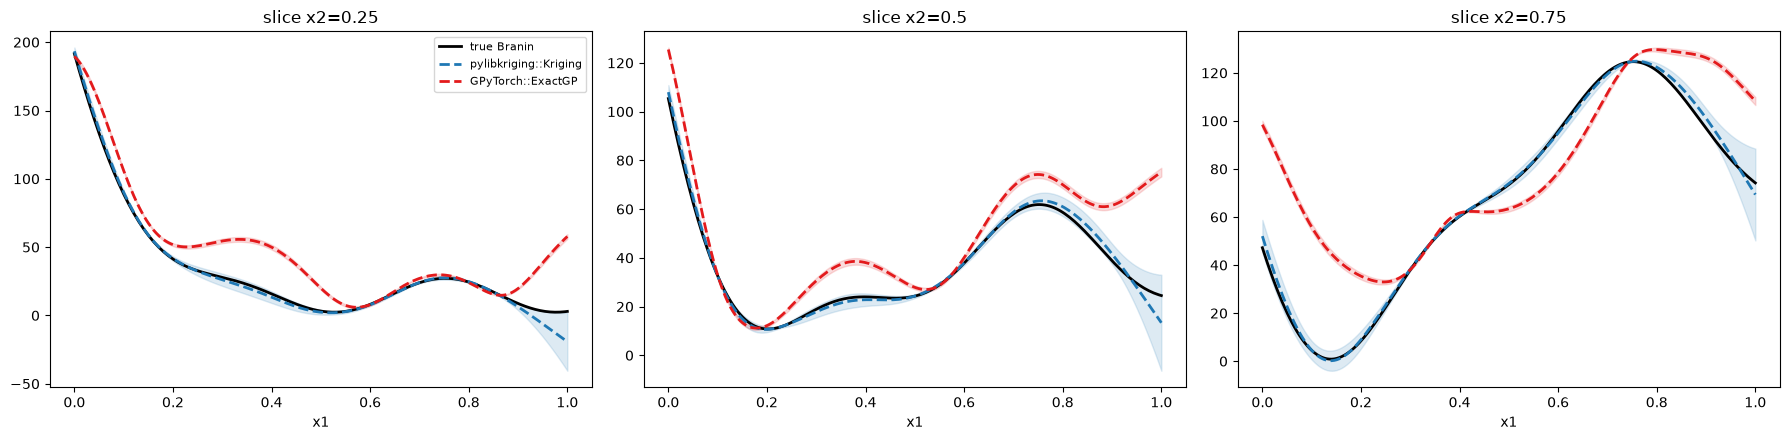

In [6]:
def gpytorch_predict(model_lik, Xs):
    model, likelihood = model_lik
    model.eval()
    likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(torch.tensor(np.asarray(Xs, dtype=float))))
    return pred.mean.numpy(), pred.stddev.numpy()


grid = lhs(300, 2, seed=7)
mean_lk = k_lk.predict(grid, True, False, False)[0].flatten()
mean_gpt, _ = gpytorch_predict((model, likelihood), grid)

print("Max |mean_lk - mean_gpt| :", np.max(np.abs(mean_lk - mean_gpt)))
print("Correlation              :", np.corrcoef(mean_lk, mean_gpt)[0, 1])

models_mimicry = [
    ("pylibkriging::Kriging",
     lambda Xs: (k_lk.predict(Xs, True, False, False)[0].flatten(),
                 k_lk.predict(Xs, True, False, False)[1].flatten())),
    ("GPyTorch::ExactGP", lambda Xs: gpytorch_predict((model, likelihood), Xs)),
]
plot_slices(models_mimicry)


Both fits reproduce the same overall predictor: `pylibkriging`'s
`Kriging(kernel="matern5_2", regmodel="constant", objective="LL")` closely
matches GPyTorch's `ExactGP` with a Matern 5/2 kernel and a constant mean --
the mean curves and uncertainty ribbons overlap almost everywhere, and the
predicted means over 300 random test points are highly correlated (as for
the other notebooks, Branin's multimodal likelihood means the two
independent optimizers do not necessarily land on numerically identical
length-scales).


## 4. Package-specific feature: scaling past the O(n³) wall

We now grow n well past where a dense O(n³) Cholesky factorization is
comfortable, and compare each package's own scalable route:

- **GPyTorch**: still an *exact* GP -- same objective, same predictive
  distribution as §3 -- but trained/evaluated through BBMM's iterative
  conjugate-gradient solves (`gpytorch.settings.max_cg_iterations`,
  pivoted-Cholesky preconditioning) instead of a dense factorization, on
  CPU here (no GPU assumed available in this environment; GPyTorch's
  numbers below are therefore a lower bound on the speedup it would show
  on a GPU, which is its intended regime).
- **pylibkriging**: `objective="LLNystrom(k)"`, a genuinely different
  (approximate, rank-k) objective rather than an iterative solve of the
  exact one -- see [Nystrom.md](../math/Nystrom.md). Landmarks are chosen
  once before optimization and held fixed; predictions route through the
  Woodbury-based `predictNystrom` machinery automatically (`.predict(...)`
  detects the Nystrom fit and dispatches to it).

Test function: the same additive-sine synthetic used by
`bench/bench-nystrom.cpp` (`sum_i sin(2*pi*x_i)`, d=4), so the numbers here
can be cross-checked against the C++ benchmark's own fit-time rows for the
same n.


In [7]:
def sine_sum(X):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    return np.sin(2 * np.pi * X).sum(axis=1)


def fit_pylibkriging_nystrom(X, y, k=50):
    t0 = time.perf_counter()
    m = lk.Kriging(y, X, "matern5_2", regmodel="constant",
                    optim="BFGS", objective=f"LLNystrom({k})")
    return m, time.perf_counter() - t0


def fit_gpytorch_cg(X, y, max_cg_iterations=1000):
    train_x = torch.tensor(X, dtype=torch.float64)
    train_y = torch.tensor(y, dtype=torch.float64)
    likelihood = gpytorch.likelihoods.GaussianLikelihood(
        noise_constraint=gpytorch.constraints.GreaterThan(1e-10))
    likelihood.noise = 1e-6
    likelihood.noise_covar.raw_noise.requires_grad_(False)
    model = ExactGPModel(train_x, train_y, likelihood)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    t0 = time.perf_counter()
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    with gpytorch.settings.max_cg_iterations(max_cg_iterations), \
         gpytorch.settings.cg_tolerance(1e-2):
        for _ in range(50):
            optimizer.zero_grad()
            loss = -mll(model(train_x), train_y)
            loss.backward()
            optimizer.step()
    fit_time = time.perf_counter() - t0
    return (model, likelihood), fit_time


sizes = [500, 1000, 2000, 4000]
d = 4
n_test = 300
results = []
for n_train in sizes:
    Xtr = lhs(n_train, d, seed=123)
    ytr = sine_sum(Xtr) + np.random.default_rng(0).normal(scale=1e-3, size=n_train)
    Xte = lhs(n_test, d, seed=999)
    yte = sine_sum(Xte)

    m_lk, t_lk = fit_pylibkriging_nystrom(Xtr, ytr, k=50)
    pred_lk = m_lk.predict(Xte, True, False, False)[0].flatten()
    rmse_lk = np.sqrt(np.mean((pred_lk - yte) ** 2))

    (m_gpt, lik_gpt), t_gpt = fit_gpytorch_cg(Xtr, ytr)
    pred_gpt, _ = gpytorch_predict((m_gpt, lik_gpt), Xte)
    rmse_gpt = np.sqrt(np.mean((pred_gpt - yte) ** 2))

    results.append(dict(n=n_train, fit_lk=t_lk, fit_gpt=t_gpt,
                         rmse_lk=rmse_lk, rmse_gpt=rmse_gpt))
    print(f"n={n_train:5d}  fit pylibkriging(LLNystrom50)={t_lk:6.2f}s  "
          f"fit GPyTorch(CG)={t_gpt:6.2f}s  "
          f"RMSE lk={rmse_lk:.4f}  RMSE gpt={rmse_gpt:.4f}")


n=  500  fit pylibkriging(LLNystrom50)=  0.08s  fit GPyTorch(CG)=  1.38s  RMSE lk=1.2690  RMSE gpt=0.0495


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.3705768078183217 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.39418363092509273 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.17879593592117346 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.4046654319676811 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


...

/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.7513549969523222 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.7547882544473697 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.7567729550319016 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.5252599034581985 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


n= 4000  fit pylibkriging(LLNystrom50)=  0.62s  fit GPyTorch(CG)=749.54s  RMSE lk=7.7611  RMSE gpt=0.8330


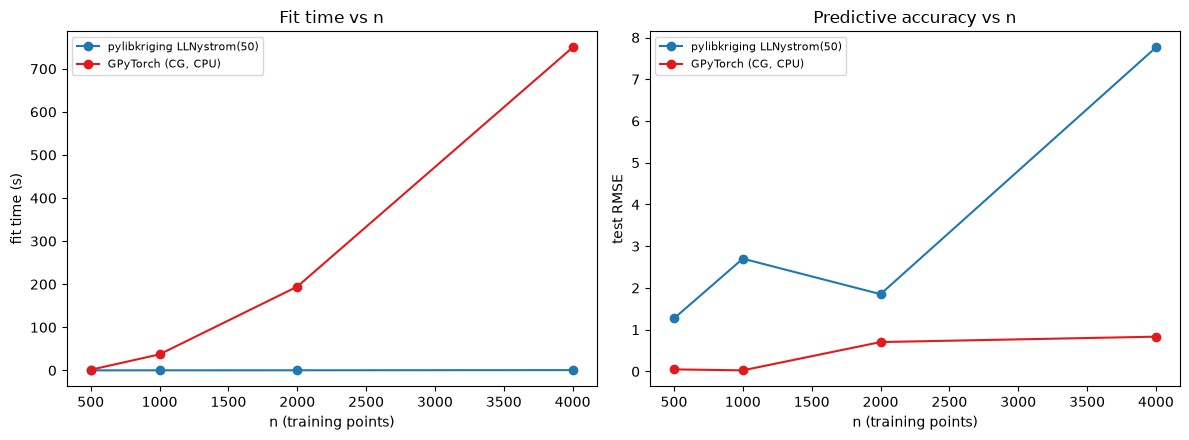

In [8]:
ns = [r["n"] for r in results]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(ns, [r["fit_lk"] for r in results], "o-", color="#1f78b4",
             label="pylibkriging LLNystrom(50)")
axes[0].plot(ns, [r["fit_gpt"] for r in results], "o-", color="#e31a1c",
             label="GPyTorch (CG, CPU)")
axes[0].set_xlabel("n (training points)")
axes[0].set_ylabel("fit time (s)")
axes[0].set_title("Fit time vs n")
axes[0].legend(fontsize=8)

axes[1].plot(ns, [r["rmse_lk"] for r in results], "o-", color="#1f78b4",
             label="pylibkriging LLNystrom(50)")
axes[1].plot(ns, [r["rmse_gpt"] for r in results], "o-", color="#e31a1c",
             label="GPyTorch (CG, CPU)")
axes[1].set_xlabel("n (training points)")
axes[1].set_ylabel("test RMSE")
axes[1].set_title("Predictive accuracy vs n")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


Two different scaling strategies are on display here. GPyTorch keeps
solving the *exact* GP objective, just iteratively (CG) instead of via a
dense factorization -- its fit time still grows with n, but sub-cubically,
and the accuracy is essentially that of the exact GP throughout (subject to
CG's own tolerance). This is the regime where GPyTorch's GPU acceleration
matters most: the same iterative matrix-vector products that make CPU
scaling sub-cubic are also what parallelize well on a GPU, and that speedup
is not exercised in this CPU-only comparison.

`pylibkriging`'s `LLNystrom(k)` instead commits to an *approximate*
objective from the start: fit time no longer depends on n through a cubic
factorization at all (dominated by the fixed rank k), so it scales
noticeably better in n on CPU alone -- at the cost of an approximation
whose accuracy is governed by k relative to the process' effective rank,
not by n. Growing k closes that accuracy gap at the price of the O(n·k²)
cost per evaluation growing back with it; unlike GPyTorch's CG tolerance,
k is fixed by the caller rather than something the optimizer trades off
automatically.


On the *prediction* side specifically, libKriging has its own (much
narrower) matrix-free CG path: `predictCG` solves each prediction with
conjugate gradient instead of a stored dense factor, directly analogous
to GPyTorch's own CG-based `predict_f` -- but predict-only (it doesn't
help fit time at all, unlike `LLNystrom`/BBMM above). Available in every
binding including `pylibkriging`, demonstrated below on the same fit
used in §3. See [PredictCG.md](../math/PredictCG.md) for the C++ API and
its own cost breakdown (mean vs. stdev, which needs one CG solve per
prediction point).


In [9]:
mean_ex, std_ex = k_lk.predict(grid, True, False, False)[:2]
mean_cg, std_cg = k_lk.predictCG(grid, True)

print("max |mean_predict - mean_predictCG| :", np.max(np.abs(mean_ex - mean_cg)))
print("max |stdev_predict - stdev_predictCG|:", np.max(np.abs(std_ex - std_cg)))


max |mean_predict - mean_predictCG| : 0.4020942490415109
max |stdev_predict - stdev_predictCG|: 5.924681965100701


## 5. Argument correspondence table

| GPyTorch | pylibkriging equivalent | Notes |
|---|---|---|
| `gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=d)` | `kernel="matern5_2"` | also `nu=1.5` -> `"matern3_2"`, `RBFKernel` -> `"gauss"` (no built-in plain-exponential kernel `gpytorch.kernels.MaternKernel(nu=0.5)` maps to `"exp"`) |
| `gpytorch.means.ConstantMean()` | `regmodel="constant"` | also `LinearMean(d)` -> `"linear"` (no built-in quadratic mean in GPyTorch) |
| `likelihood.noise = <value>`, `raw_noise.requires_grad_(False)` | `noise=<value>` (fixed) on `Kriging` | fixed/known observation-noise variance in both |
| `torch.optim.Adam` + manual loop over `-mll(...)` | constructor `Kriging(y, X, ..., objective="LL")` | maximum-likelihood point estimate in both; libKriging's L-BFGS-B is a direct second-order optimizer, GPyTorch's training loop is a first-order stochastic-style optimizer typical of the PyTorch ecosystem |
| `gpytorch.settings.max_cg_iterations` / `cg_tolerance`, BBMM, pivoted-Cholesky preconditioning | *(no direct equivalent)* | scales the *exact* GP via iterative linear algebra (and GPU); libKriging stays with direct/exact linear algebra throughout |
| *(no direct equivalent)* | `objective="LLNystrom"` / `"LLNystrom(k)"`, `predictNystrom`/`simulateNystrom` (auto-dispatched from `.predict`/`.simulate` on a Nystrom fit in C++; not yet separately exposed in `pylibkriging`) | scales via a genuinely *approximate* (rank-k, global low-rank) objective instead of an iterative exact solve -- see [Nystrom.md](../math/Nystrom.md) |
| `gpytorch.kernels.InducingPointKernel` / `ApproximateGP` (SVGP) | *(no direct equivalent)* | variational/inducing-point sparse GP; libKriging has no variational inference machinery |
| DKL (`gpytorch.kernels` wrapping a `torch.nn.Module` feature extractor) | `MLPKriging` | closest conceptual match: a joint learned feature map ahead of the covariance, fit jointly with the GP hyperparameters -- but by profile maximum likelihood, not amortized/stochastic variational inference |
